In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.typing as npt


: 

In [ ]:
imgs = np.fromfile("Images/train-images-idx3-ubyte", dtype=np.uint8)
imgs = np.reshape(imgs[16:], [-1, 28, 28])

labs = np.fromfile("Images/train-labels-idx1-ubyte", dtype=np.uint8)
labs = labs[8:]

imgs_test = np.fromfile("Images/t10k-images-idx3-ubyte",dtype=np.uint8)
imgs_test = np.reshape(imgs_test[16:], [-1, 28, 28])

labs_test = np.fromfile("Images/t10k-labels-idx1-ubyte",dtype=np.uint8)
labs_test = labs_test[8:]

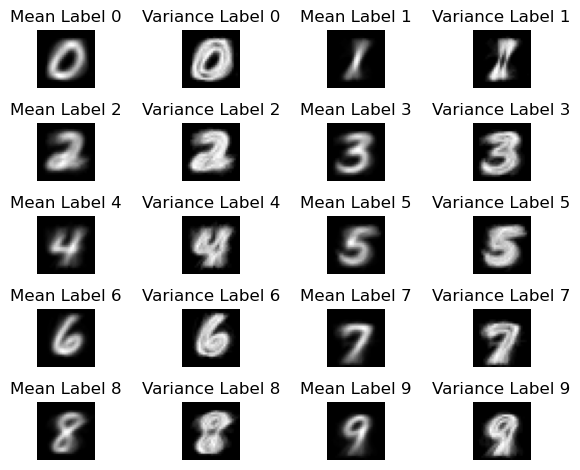

In [9]:
def mean(x:npt.ArrayLike) -> npt.ArrayLike:
    """
    Calculates the mean  for a set
    of images x  
    """
    return np.mean(x,axis=0)

def var(x:npt.ArrayLike)-> npt.ArrayLike:
    """
    Calculates the variance  for a set
    of images x  
    """
    return np.var(x,axis=0)


def plot_mean_variance(imgs:npt.NDArray[np.uint8],labs:npt.NDArray[np.uint8])-> None:
    """
    Visualizes the mean and the variance of the first 100 training images per digit.

    Args:
        imgs: Training images from the MNIST dataset
        labs: Labels from the MNIST dataset

    """
    for i in range (10):
        index = []
        for j,k in enumerate(labs):
            if k == i:
                index.append(j)
        cond = (index[:100])
        img = imgs[cond]

        m = mean(img)
        v = var(img)

        plt.subplot(5,4,2*i+1)
        plt.imshow(m,cmap="gray")
        plt.title(f'Mean Label {i}')
        plt.axis('off')

        plt.subplot(5,4,2*i+2)
        plt.imshow(v,cmap="gray")
        plt.title(f'Variance Label {i}')
        plt.axis('off')
    plt.tight_layout()

plot_mean_variance(imgs,labs)


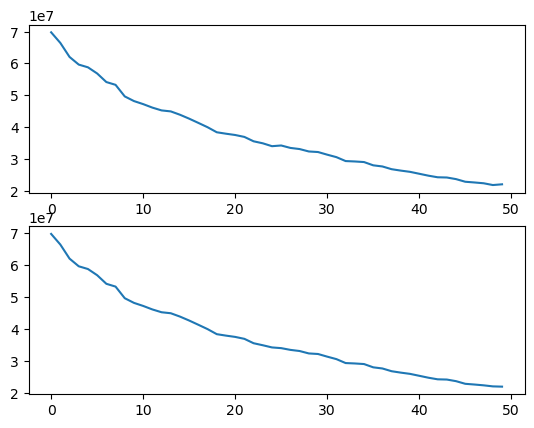

In [10]:
def plot_eigenvalues(imgs:npt.NDArray[np.uint8])-> None:
    """
    Calculates the eigenvalues of the covariance matrix and
    the singular values of the 1000 training images.
    Visualizes the first 50 eigenvalues and the squared 
    singular values
    
    Args:
        imgs: Training images from the MNIST dataset
    """
    m = mean(imgs)

    Y = imgs - m
    Y = Y[:1000]
    Y = Y.reshape(784,-1)
    Y_T = np.transpose(Y)

    S = Y @ Y_T
    eigenvals =  np.linalg.eigvals(S)
    eigenvals = eigenvals[:50]

    plt.subplot(2,1,1)
    plt.plot(eigenvals)

    U,S_new,Vh = np.linalg.svd(Y,full_matrices=True)

    Sv = S_new[:50]
    S_eigenval = np.square(S_new)
    plt.subplot(2,1,2)
    plt.plot(S_eigenval[:50])

plot_eigenvalues(imgs)

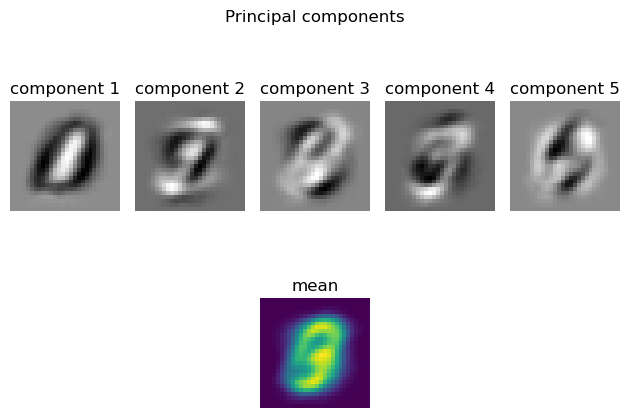

In [22]:
def affine_subspace(x:npt.NDArray[np.uint8])-> tuple[npt.NDArray[np.uint8],npt.NDArray[np.uint8]]:
    """
    Calculates the best possible d-dimensional affine subspace

    Args:
        x: Training images from the MNIST dataset

    returns:
        A: the first 5 eigenvectors
        b: the mean of the provided training images
    """
    b = mean(x)
    x = x-b 

    U,S,Vh = np.linalg.svd(x,full_matrices=False)
    A =  Vh.T[:,:5]
     
    return A,b

def plot_principal_components(imgs:npt.NDArray[np.uint8])->None:   
    """
    Visualizes the mean and the first five principal components
    of the first 1000 training images.

    Args:
        imgs: Training images from the MNIST dataset
    """
    Y_new = imgs[:1000]
    Y_new = Y_new.reshape(1000,-1)

    eigvec,m = affine_subspace(Y_new)

    for i in range(5): 
        plt.subplot(2,5,i+1)
        plt.imshow(eigvec[:,i].reshape(28,28),cmap="gray")
        plt.axis("off")
        plt.title(f'component {i+1}')
    plt.suptitle("Principal components")

    plt.subplot(2,5,8)
    plt.imshow(m.reshape(28,28))
    plt.title("mean")
    plt.axis('off')
    plt.tight_layout()

plot_principal_components(imgs)

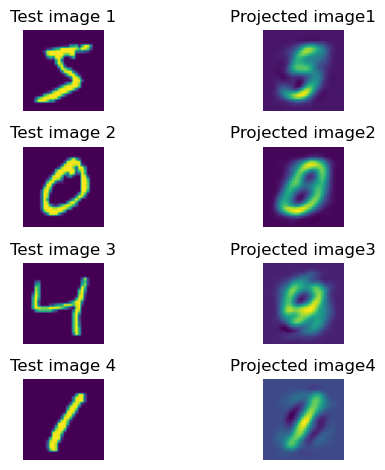

In [ ]:
def test_subspace(A:npt.NDArray[np.uint8],x:npt.NDArray[np.uint8],b:npt.NDArray[np.uint8])-> npt.NDArray[np.float64]:
    """
    Projects test images onto the subspace H

    Args:
        A: Eigenvectors from the affine_subspace function
        x: Test images from the MNIST dataset
        b: Mean of the affine_subspace function
    """
    return (A @(A.T @ (x-b))+b)

def plot_projection(imgs:npt.NDArray[np.uint8],A:npt.NDArray[np.uint8],b:npt.NDArray[np.uint8])->None:
    """
    Visualizes the test images and their assoicated
    projection side by side using the test_subspace function

    Args:
        imgs: Test images from the MNIST dataset
    """

    im = imgs[:4]
    im = im.reshape(4,-1)

    for i in range(4):
        im_new = im[i]
        im_subspace = test_subspace(A,im[i],b)

        plt.subplot(4,2,(2*i)+1)
        plt.imshow(im[i].reshape(28,28))
        plt.axis('off')
        plt.title(f"Test image {i+1}")

        plt.subplot(4,2,2*i+2)
        plt.imshow(im_subspace.reshape(28,28))
        plt.axis('off')
        plt.title(f"Projected image{i+1}")
    plt.tight_layout()


Y_new = imgs[:1000].reshape(1000,-1)

A,b = affine_subspace(Y_new)
plot_projection(imgs,A,b)



In [13]:
def K_means(x:npt.NDArray[np.uint8],K:int, center_list:list = None, iter:int =1000)->list:
    """
    Implements the K-Means algorithm for a number
    of clusters K and a set of images x

    Args:
        x: Training images of the MNIST dataset
        K: Number of clusters into which the images are divided
        center: The initial values of the clusters
        iter: Number of iterations in which the clusters are updatet
    """
    _,d = x.shape
    if center_list is None:
        centers = []
        for i in range(K):
            r = np.random.rand(d)
            centers.append(r)

    else:
        centers = center_list

    for _ in range(iter):

        classes = []
        for x_i in x:
            distances = []
            for r_k in centers:
                distance = np.linalg.norm(x_i-r_k)**2
                distances.append(distance)
            k = np.argmin(distances)
            classes.append(k) 
        for i,center in enumerate(centers):
            points = []
            for j,point in enumerate(x):
                if classes[j] == i:
                    points.append(point)
            if len(points) > 0:
                centers[i] = np.mean(points,axis=0)
    return classes

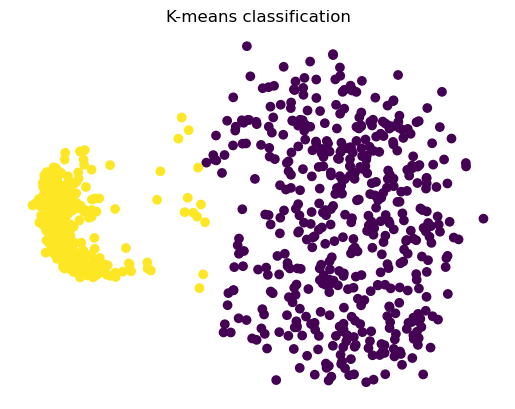

In [14]:
def plot_cluster(imgs:npt.NDArray[np.uint8],labs:npt.NDArray[np.uint8])-> None:
    """
    Divides the projected images into two classes and
    visualizes the classification

    Args:
        imgs: Training images from the MNIST dataset
        labs: Labels from the MNIST dataset
    """

    imgs_list = []
    for i in range (2):
        index = []
        for j,k in enumerate(labs):
            if k == i:
                index.append(j)
        cond = (index[:500])
        img = imgs[cond]
        imgs_list.append(img)

    imgs_list = np.asarray(imgs_list)
    imgs_list = imgs_list.reshape(1000,-1)

    b = mean(imgs_list)
    x = imgs_list-b 

    U,S,Vh = np.linalg.svd(x,full_matrices=False)
    A =  Vh.T[:,:2]
    projected_image = (imgs_list-b) @ A

    mean0 = mean(projected_image[:500])
    mean1= mean(projected_image[500:1000])
    center = []
    center.append(mean0) 
    center.append(mean1)

    arr = K_means(projected_image,K=2,center_list=center)
    arr = np.asarray(arr)
    arr_0 = np.where(arr==0)
    arr_1 = np.where(arr==1)

    plt.scatter(projected_image[:,0],projected_image[:,1],c=arr)
    plt.title("K-means classification")
    plt.axis('off')

plot_cluster(imgs,labs)

In [15]:
def classify_test_images(imgs_test:npt.NDArray[np.uint8],labs_test:npt.NDArray[np.uint8],A:npt.NDArray[np.uint8],b:npt.NDArray[np.uint8],center:list)->None:
    """
    Classifies the test images and presents the
    correct and incorrect classifications by digit in a table
    
     Args:
        imgs_test: Test images from the MNIST dataset
        labs_test: Test labels from the MNIST dataset
    """

    imgs_test_list = []

    for i in range (2):
        index = []
        for j,k in enumerate(labs_test):
            if k == i:
                index.append(j)
        cond = (index[:100])
        img = imgs_test[cond]
        imgs_test_list.append(img)

    imgs_test_list = np.asarray(imgs_test_list)
    imgs_test_list = imgs_test_list.reshape(200,-1)

    projected_image = (imgs_test_list-b) @ A
    
    arr = K_means(projected_image,K=2,center_list=center)
    arr = np.asarray(arr)

    lab_zeros = np.zeros(100)
    lab_ones = np.ones(100)
    labels = np.concatenate((lab_zeros,lab_ones))


    true_0 = np.sum((labels == 0) & (arr == 0))
    false_0 = np.sum((labels == 0) & (arr == 1))
    true_1 = np.sum((labels == 1) & (arr == 1))
    false_1 = np.sum((labels == 1) & (arr == 0))


    print("Classification of the test images")
    print("Digit 0:")
    print(f"correctly classified: {true_0}")
    print(f"misclassified: {false_0}")
    print("Digit 1:")
    print(f"correctly classified: {true_1}")
    print(f"misclassified: {false_1}")

imgs_list = []
for i in range (2):
    index = []
    for j,k in enumerate(labs):
        if k == i:
            index.append(j)
    cond = (index[:500])
    img = imgs[cond]
    imgs_list.append(img)

imgs_list = np.asarray(imgs_list)
imgs_list = imgs_list.reshape(1000,-1)

b = mean(imgs_list)
x = imgs_list-b 

U,S,Vh = np.linalg.svd(x,full_matrices=False)
A =  Vh.T[:,:2]
projected_image = (imgs_list-b) @ A

mean0 = mean(projected_image[:500])
mean1= mean(projected_image[500:1000])
center = []
center.append(mean0) 
center.append(mean1)

classify_test_images(imgs_test,labs_test,A,b,center)

Classification of the test images
Digit 0:
correctly classified: 98
misclassified: 2
Digit 1:
correctly classified: 100
misclassified: 0
